# InterScale Pipeline: Local Model

Local Model = Graph Convolutional Neural Network

Data: CosmX Pancreas

In [1]:
import scanpy as sc

import InterScale as interscale
from InterScale.config import load_config
from graph_transformer_long_range_niches.pp import split_adata
from InterScale.tl import prepare_geome_dataset, check_and_update_cfg
from InterScale.geome_dataloader import GraphAnnDataModule

# from graph_transformer_long_range_niches.config import load_config
# from graph_transformer_long_range_niches.pp import sliding_window

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Imp

In [11]:
CFG_PATH_GRAPH = "/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/CosmX_Pancreas/pancreas_graph_sample_gnn.yaml"
#CFG_PATH_GRAPH = "/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/Legnini_23/legnini23_graph_sample_LocalModel_gnn.yaml"
#CFG_PATH_GRAPH = "/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/legnini23/pancreas_graph_sample_gnn.yaml"
CFG_PATH_REG = "/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/CosmX_Pancreas/pancreas_genes_sw_gnn.yaml"

## 0. Load and prepare data

We load a subset of the CosmX pancreas data containing T1D (type 1 diabetes) and ND (no diabetes) samples and the config file with the model specifications. 

In [12]:
cfg = load_config(CFG_PATH_GRAPH)
cfg

CfgNode({'wandb': CfgNode({'use': False, 'project_name': 'GTLongRange_CosmXPancreas'}), 'model': CfgNode({'n_embed': 128, 'local_component': CfgNode({'name': 'GCN', 'load': None, 'parameters': CfgNode({'hidden_dim': 256, 'num_layers': 2, 'dropout_local': 0.15})}), 'global_component': CfgNode({'name': None, 'load': None}), 'save': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/results/cosmx_pancreas/', 'loss': None, 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1})}), 'optim': CfgNode({'lr': 0.0001, 'use_lr_scheduler': True, 'lr_warmup': 20, 'lr_max_epochs': 100, 'wd': 0.0001, 'loss': 'WeightedCE', 'seed': 40, 'cross_corr': 'gene', 'n_epochs': 100}), 'dataset': CfgNode({'h5ad_data': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/cosmx_pancreas.h5ad', 'name': 'pancreas', 'description': '', 'prediction_task': 'classification', 'prediction_obs': 'condition', 'prediction_level': 'graph', 'la

In [13]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_fov'
    layers: 'counts'

In [14]:
import pandas as pd
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['split_0', 'condition', 'slide']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

split_0  condition  slide     
test     T1D        Run5211_S3    100230
val      T1D        Run5211_S2     77807
train    ND         Run5211_S1     61460
test     ND         Run5211_S3     51365
val      ND         Run5211_S2     48614
train    T1D        Run5211_S1     47251
Name: count, dtype: int64


In [15]:
adata.obs['slide_fov']

1_1_1         1_1
1_2_1         1_1
1_3_1         1_1
1_4_1         1_1
1_5_1         1_1
             ... 
3_7236_25    3_25
3_7237_25    3_25
3_7239_25    3_25
3_7240_25    3_25
3_7241_25    3_25
Name: slide_fov, Length: 386727, dtype: category
Categories (71, object): ['1_1', '1_2', '1_3', '1_4', ..., '3_22', '3_23', '3_24', '3_25']

## 1. Data setup

We need to specify:

- `prediction_task`: Prediction task can either be classification or regression
- `prediction_level`: Which level the predictions should be performed on: either (1) tissue label, e.i. condition (`graph`), (2) node label (`node`) for cell type or niche prediciton, or (3) GEX prediction.

Additionally, we define dataset specific keys: 
- `prediction_obs`: Label in `adata.obs` to be predicted. Only required for classification tasks.
- `layer_key`: Defines which GEX matrix to retrieve from `adata.layer`
- `sample_key`: `adata.obs` used to split the samples into PyG Data objects
- `group_label`: Optional: only if we have a `adata.obs` group that we want to stratify during sampling

In [21]:
PREDICTION_TASK = 'classification'
PREDICTION_LEVEL = 'graph'

prediction_obs = 'condition'
layer_key = None
sample_key = ['sliding_window_square']
group_label = 'condition'

In [22]:
cfg = check_and_update_cfg(cfg, prediction_task = PREDICTION_TASK, prediction_level = PREDICTION_LEVEL, layer_key = layer_key, sample_key = sample_key, prediction_obs = prediction_obs)

Update sample key (from '['sliding_window_square']' to '['sliding_window_square']')


In [23]:
interscale.model.LocalModel._setup_anndata(adata = adata, prediction_task = PREDICTION_TASK, layer_key = layer_key, sample_key_list = sample_key, prediction_obs = prediction_obs, group_key = group_label)

Anndata setup with scvi-tools version 1.3.0.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│   n_group_key    │   2   │
│ n_prediction_obs │   2   │
│  n_sample_key_0  │  596  │
│       n_x        │  979  │
└──────────────────┴───────┘

                    Data Registry                     
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃  Registry Key  ┃        scvi-tools Location        ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│   group_key    │   adata.obs['_scvi_group_key']    │
│ prediction_obs │ adata.obs['_scvi_prediction_obs'] │
│  sample_key_0  │  adata.obs['_scvi_sample_key_0']  │
│       x        │              adata.X              │
└────────────────┴───────────────────────────────────┘

                         sample_key_0 State Registry                         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃          Source Location           ┃   Categories   ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_square'] │  1_4_window_0  │          0          │
│                                    │  1_8_window_0  │          1          │
│                                    │ 1_10_window_0  │          2          │
│                                    │ 1_11_window_0  │          3          │
│                                    │ 1_16_window_0  │          4          │
│                                    │ 1_18_window_0  │          5          │
│                                    │ 1_19_window_0  │          6          │
│                                    │ 1_22_window_0  │          7          │
│                                    │ 1_23_window_0  │          8          │
│                                    │ 1_24_window_0  │          9          │
│                                    │  2_1_window_0  │         10          │
│                                    │  2_2_window_0  │         11          │
│                                    │  2_5_window_0  │         12          │
│                                    │  2_7_window_0  │         13          │
│                                    │  2_9_window_0  │         14          │
│                                    │ 2_10_window_0  │         15          │
│                                    │ 2_11_window_0  │         16          │
│                                    │ 2_12_window_0  │         17          │
│                                    │ 2_17_window_0  │         18          │
│                                    │ 2_20_window_0  │         19          │
│                                    │ 2_22_window_0  │         20          │
│                                    │  3_1_window_0  │         21          │
│                                    │  3_4_window_0  │         22          │
│                                    │  3_5_window_0  │         23          │
│                                    │  3_7_window_0  │         24          │
│                                    │  3_8_window_0  │         25          │
│                                    │ 3_10_window_0  │         26          │
│                                    │ 3_12_window_0  │         27          │
│                                    │ 3_13_window_0  │         28          │
│                                    │ 3_14_window_0  │         29          │
│                                    │ 3_20_window_0  │         30          │
│                                    │  1_1_window_1  │         31          │
│                                    │  1_2_window_1  │         32          │
│                                    │  1_4_window_1  │         33          │
│                                    │  1_7_window_1  │         34          │
│                                    │  1_8_window_1  │         35          │
│                                    │  1_9_window_1  │         36          │
│                                    │ 1_10_window_1  │         37          │
│                                    │ 1_12_window_1  │         38          │
│                                    │ 1_16_window_1  │         39          │
│                                    │ 1_17_window_1  │         40          │
│                                    │ 1_18_window_1  │         41          │
│                                    │ 1_19_window_1  │         42          │
│                                    │ 1_20_window_1  │         43          │
│                                    │ 1_21_window_1  │         44          │
│                                    │ 1_22_window_1  │         45          │
│                                    │ 1_23_window_1  │         46          │
│                     

                prediction_obs State Registry                
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

                  group_key State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [24]:
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_prediction_obs', '_scvi_group_key'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_fov'
    layers: 'counts'

## 2. Model setup

Either set up the model from scratch or load trained model from file (Section 4).

In [25]:
model = interscale.model.LocalModel(
    adata,
    cfg = cfg
)

Class weights [1.19774961 0.85829472]


In [26]:
model._model_summary_string

'classification model for graph prediction. \n'

## 3. Training

In [27]:
#split_adata(adata, split_obs='sample', val_size=cfg.dataset.val_size, test_size=cfg.dataset.test_size, seed = cfg.optim.seed, stratify_groups = cfg.dataset.group_label)
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)
dm = GraphAnnDataModule(datas=pyg_data_list, 
                           num_workers=1, 
                           batch_size=int(cfg.dataset.batch_size), 
                           pct_mask_nodes=cfg.dataset.pct_mask_nodes,
                           learning_type="node")

Split key split_2 already exists in adata.obs
coord_type: generic
library_key: sliding_window_square
n_neighs: 6
radius: 50
call new


/ictstr01/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


{'condition': ['ND', 'T1D']}
call new


/ictstr01/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


{'condition': ['ND', 'T1D']}
call new


/ictstr01/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


{'condition': ['ND', 'T1D']}
call new


/ictstr01/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


{'condition': ['ND', 'T1D']}
Masked dataloader


In [28]:
len(dm.train_data)

179

In [29]:
# for now training only works with datamodule. TODO: Add DataSplitter for datamodule independent training.
model.train(max_epochs = 50, 
           datamodule = dm,
           early_stopping = True)

classification
WeightedCE
Steps per epoch 12


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /ictstr01/groups/ml01/workspace/francesca.drummer/ma ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /ictstr01/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/results/cosmx_pancreas exists and is not empty.

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | module  | GCN              | 284 K  | train
1 | metrics | MetricCollection | 0  

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.5542091131210327     │
│      val_f1/class_0       │    0.5388371348381042     │
│      val_f1/class_1       │    0.5512257218360901     │
│     val_f1_macro/avg      │    0.5450313687324524     │
│     val_f1_micro/avg      │    0.5542091131210327     │
│         val_loss          │    1.2109604138311998     │
└───────────────────────────┴───────────────────────────┘

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:476: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=5` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.5982987880706787     │
│      test_f1/class_0      │    0.6512625217437744     │
│      test_f1/class_1      │    0.4902319610118866     │
│     test_f1_macro/avg     │    0.5707471966743469     │
│     test_f1_micro/avg     │    0.5982987880706787     │
│         test_loss         │    0.8456600201959598     │
└───────────────────────────┴───────────────────────────┘

Model checkpoint will be saved in:  /lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/results/cosmx_pancreas/pancreas_clas_graph_GCN_model.pt


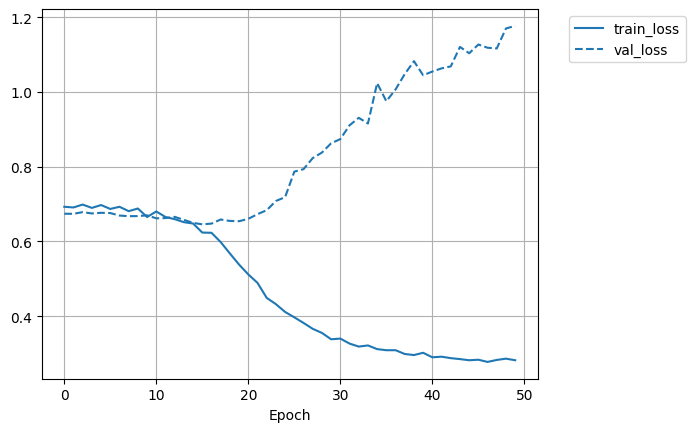

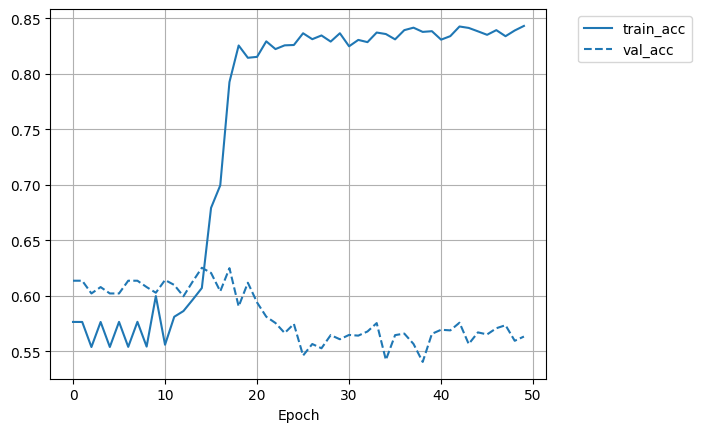

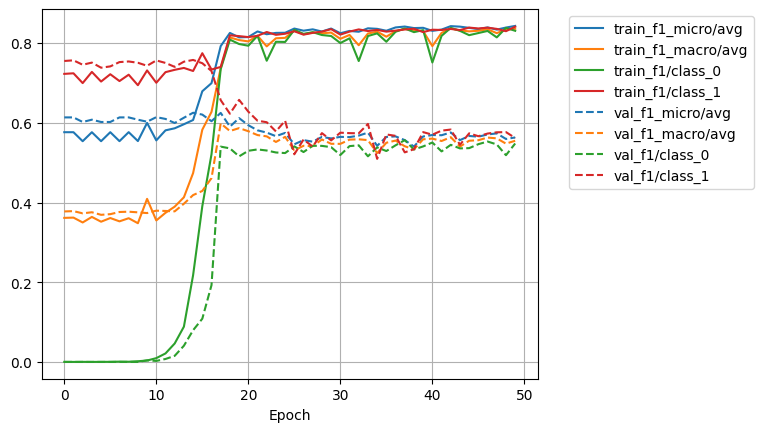

In [30]:
model.history_.plot_history(subset_term = 'loss')
model.history_.plot_history(subset_term = 'acc')
model.history_.plot_history(subset_term = 'f1')

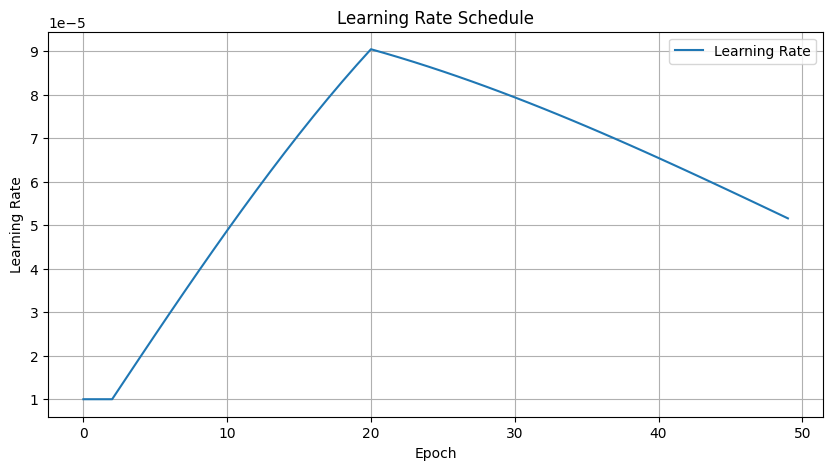

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert the history to a DataFrame
history_df = pd.DataFrame(model.history_.history)  # This is the correct attribute name

# Plot the learning rate
plt.figure(figsize=(10, 5))
plt.plot(history_df['epoch'], history_df['lr-AdamW'], label='Learning Rate')  # Using AdamW since that's what your code uses
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.grid(True)
plt.legend()
plt.show()

After first model update it unlearns to predict class 1 and only predicts class 0. Why? can we see the same thing for the GlobalModel?

## 4. Model saving and loading

In [ ]:
model.save('/ictstr01/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/model/')

In [ ]:
model = interscale.model.LocalModel.load('/ictstr01/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/model/', adata, cfg)

In [ ]:
model

## 5. Evaluation

Evaluation can either be run on the entire AnnData that the model was set up with or subsets of AnnData defined by sample_id from `adata.obs[sample_key]`.

For the LocalModel we get:

- `adata.obsm.local_emb`: Local embedding values for each cell [N,E]
- `adata.obsm.decoder_weight`: Decoder weight values for the cells [N,F]

In [ ]:
sub_adata = adata[adata.obs['condition'] == 'SHH']

In [ ]:
result = model.get_model_output(sub_adata)

In [ ]:
result

### Tissue level analysis

Can we detect a pattern across cells in which are more and less relevant to predict the condition? 

No cell types so need to categorize them differently. 

1. SHH expressed or not (Distance to SHH source)
2. What analysis could we perform without knowing that the SHH is the source for variation? Can we somehow trace the changes back to genes? 

In [ ]:
# plot celltype x condition 
import pandas as pd

def summarise_decoder_weight_by_group_and_condition(
    adata, 
    group_obs: str,
    condition_obs: str = '_scvi_prediction_obs', 
    decoder_weight_key: str = 'decoder_weight', 
):
    """
    Summarizes average attention weights for each (group_obs x condition_obs) combination.
    
    Parameters
    ----------
    adata : AnnData
        AnnData object containing attention weights in adata.obsm[decoder_weight_key].
    decoder_weight_key : str
        Key for the attention weight matrix in adata.obsm.
    condition_obs : str
        Column name in adata.obs for condition (e.g., 'disease_status').
    group_obs : str
        Column name in adata.obs for group (e.g., 'cell_type').
        
    Returns
    -------
    pd.DataFrame
        Multi-index DataFrame with average attention weights for each group x condition.
        Rows: (group_obs, condition_obs)
        Columns: attention per target cell type (from decoder_weight_key).
    """
    # Extract relevant data
    weight = adata.obsm[decoder_weight_key]
    group = adata.obs[group_obs]
    condition = adata.obs[condition_obs]
    
    # Create DataFrame for easy grouping
    df = pd.DataFrame(
        weight, 
        columns=[f"{decoder_weight_key}_{i}" for i in range(weight.shape[1])]
    )
    df[group_obs] = group.values
    df[condition_obs] = condition.values
    
    # Group by group_obs and condition_obs, then average
    grouped = df.groupby([group_obs, condition_obs]).mean()
    
    return grouped

In [ ]:
summarise_decoder_weight_by_group_and_condition(
    result, 
    condition_obs = 'shh_cluster', 
    group_obs = 'condition'
)

In [ ]:
data_list